In [1]:
# QUESTION 1: UNDERSTANDING THE DATASET

In [2]:
# Load and examine the dataset

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier 
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                           f1_score, confusion_matrix, classification_report, 
                           roc_auc_score, roc_curve)


In [4]:
# Set display options
pd.set_option('display.max_columns', None)

In [5]:
# Load the dataset
df = pd.read_csv('Car_Insurance_Claim_Prediction_dataset.csv')

In [6]:
# Display basic information
print("DATASET OVERVIEW")
print(f"Observations: {df.shape[0]:,}")
print(f"Columns: {df.shape[1]}")
print(f"Predictors: {df.shape[1] - 1}")
print("Target variable: is_claim")

DATASET OVERVIEW
Observations: 58,592
Columns: 44
Predictors: 43
Target variable: is_claim


In [7]:
# Display data types
print("VARIABLE DATA TYPES")
print(df.dtypes.value_counts())

VARIABLE DATA TYPES
object     28
int64      12
float64     4
Name: count, dtype: int64


In [8]:
# Display column names and data types
print("\nColumn Details:")
for col in df.columns:
    dtype = df[col].dtype
    if dtype == 'object':
        unique_count = df[col].nunique()
        print(f"  {col}: {dtype} (Unique values: {unique_count})")
    else:
        print(f"  {col}: {dtype}")


Column Details:
  policy_id: object (Unique values: 58592)
  policy_tenure: float64
  age_of_car: float64
  age_of_policyholder: float64
  area_cluster: object (Unique values: 22)
  population_density: int64
  make: int64
  segment: object (Unique values: 6)
  model: object (Unique values: 11)
  fuel_type: object (Unique values: 3)
  max_torque: object (Unique values: 9)
  max_power: object (Unique values: 9)
  engine_type: object (Unique values: 11)
  airbags: int64
  is_esc: object (Unique values: 2)
  is_adjustable_steering: object (Unique values: 2)
  is_tpms: object (Unique values: 2)
  is_parking_sensors: object (Unique values: 2)
  is_parking_camera: object (Unique values: 2)
  rear_brakes_type: object (Unique values: 2)
  displacement: int64
  cylinder: int64
  transmission_type: object (Unique values: 2)
  gear_box: int64
  steering_type: object (Unique values: 3)
  turning_radius: float64
  length: int64
  width: int64
  height: int64
  gross_weight: int64
  is_front_fog_lig

In [9]:
# Checking for missing values, duplicates and class distribution

In [10]:
print("DATA QUALITY ASSESSMENT")

# Check for missing values
missing_values = df.isnull().sum()
missing_percentage = (missing_values / len(df)) * 100
missing_df = pd.DataFrame({'Missing Values': missing_values, 'Percentage': missing_percentage})
print("\nMissing Values:")
print(missing_df[missing_df['Missing Values'] > 0])

DATA QUALITY ASSESSMENT

Missing Values:
Empty DataFrame
Columns: [Missing Values, Percentage]
Index: []


In [11]:
# Check for duplicate observations
duplicates = df.duplicated().sum()
print(f"\nDuplicate observations: {duplicates}")


Duplicate observations: 0


In [12]:
# Check class distribution of target variable
print("TARGET VARIABLE DISTRIBUTION")
claim_counts = df['is_claim'].value_counts()
claim_percentages = df['is_claim'].value_counts(normalize=True) * 100

print(f"Class 0 (No Claim): {claim_counts[0]:,} ({claim_percentages[0]:.2f}%)")
print(f"Class 1 (Claim):   {claim_counts[1]:,} ({claim_percentages[1]:.2f}%)")


TARGET VARIABLE DISTRIBUTION
Class 0 (No Claim): 54,844 (93.60%)
Class 1 (Claim):   3,748 (6.40%)


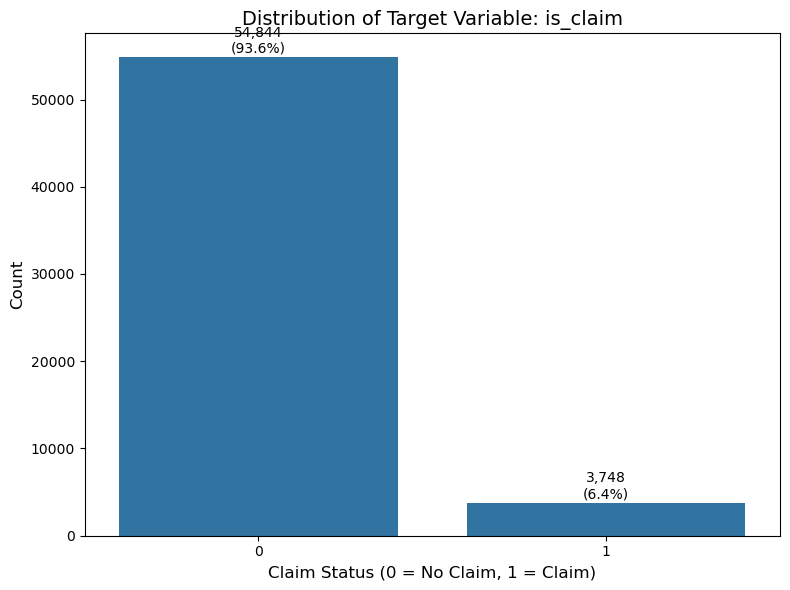

In [13]:
plt.figure(figsize=(8, 6))
sns.countplot(x='is_claim', data=df) 
plt.title('Distribution of Target Variable: is_claim', fontsize=14)
plt.xlabel('Claim Status (0 = No Claim, 1 = Claim)', fontsize=12)
plt.ylabel('Count', fontsize=12)

total = len(df)
for i, val in enumerate(claim_counts):
    percentage = (val / total) * 100
    plt.text(i, val + 500, f'{val:,}\n({percentage:.1f}%)', ha='center', fontsize=10)

plt.tight_layout()
plt.savefig('target_distribution.png', dpi=300)
plt.show()

In [14]:
# QUESTION 2: PREPARING THE DATA 

In [15]:
# Create a working copy to avoid modifying original
df_clean = df.copy()

# Remove policy_id (identifier only)
df_clean = df_clean.drop('policy_id', axis=1)

# Separate features and target
X = df_clean.drop('is_claim', axis=1)
y = df_clean['is_claim']

print(f"Features (X): {X.shape[1]} variables")
print(f"Target (y): {y.shape[0]} observations")
print(f"Target distribution:\n{y.value_counts()}")

Features (X): 42 variables
Target (y): 58592 observations
Target distribution:
is_claim
0    54844
1     3748
Name: count, dtype: int64


In [16]:
# Train-test split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"   Training set: {len(X_train):,} observations")
print(f"   Test set: {len(X_test):,} observations")

   Training set: 46,873 observations
   Test set: 11,719 observations


In [17]:
# Identify categorical variables (object type, excluding Boolean)
categorical_cols = [col for col in X.columns if X[col].dtype == 'object']

print(f"Categorical variables to encode: {len(categorical_cols)}")
print(f"  {categorical_cols}")

Categorical variables to encode: 27
  ['area_cluster', 'segment', 'model', 'fuel_type', 'max_torque', 'max_power', 'engine_type', 'is_esc', 'is_adjustable_steering', 'is_tpms', 'is_parking_sensors', 'is_parking_camera', 'rear_brakes_type', 'transmission_type', 'steering_type', 'is_front_fog_lights', 'is_rear_window_wiper', 'is_rear_window_washer', 'is_rear_window_defogger', 'is_brake_assist', 'is_power_door_locks', 'is_central_locking', 'is_power_steering', 'is_driver_seat_height_adjustable', 'is_day_night_rear_view_mirror', 'is_ecw', 'is_speed_alert']


In [18]:
# Apply One-Hot Encoding

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.fit(X_train[categorical_cols])

X_train_encoded = encoder.transform(X_train[categorical_cols])
X_test_encoded = encoder.transform(X_test[categorical_cols])

encoded_features = encoder.get_feature_names_out(categorical_cols)
print(f"   New features created: {len(encoded_features)}")

   New features created: 112


In [19]:
# Identify numerical features
numerical_features = [col for col in X.columns if X[col].dtype in ['int64', 'float64']]
print(f"   Found {len(numerical_features)} numerical features")

   Found 15 numerical features


In [20]:
# Apply feature scaling

scaler = StandardScaler()
X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numerical_features] = scaler.fit_transform(X_train[numerical_features])
X_test_scaled[numerical_features] = scaler.transform(X_test[numerical_features])
print(f"   Scaler fitted on training data only")

   Scaler fitted on training data only


In [21]:
# Combine encoded and scaled features

# Create dataframes for encoded features
X_train_encoded_df = pd.DataFrame(X_train_encoded, columns=encoded_features, index=X_train.index)
X_test_encoded_df = pd.DataFrame(X_test_encoded, columns=encoded_features, index=X_test.index)

# Combine numerical and encoded features
X_train_final = pd.concat([
    X_train_scaled[numerical_features].reset_index(drop=True),
    X_train_encoded_df.reset_index(drop=True)
], axis=1)

X_test_final = pd.concat([
    X_test_scaled[numerical_features].reset_index(drop=True),
    X_test_encoded_df.reset_index(drop=True)
], axis=1)

print(f"   Final training data shape: {X_train_final.shape}")
print(f"   Final test data shape: {X_test_final.shape}")


   Final training data shape: (46873, 127)
   Final test data shape: (11719, 127)


In [22]:
# Check for data leakage

print("Data Leakage Check")
print(f"Training missing values: {X_train_final.isnull().sum().sum()}")
print(f"Test missing values: {X_test_final.isnull().sum().sum()}")

print("Data preparation complete.")

Data Leakage Check
Training missing values: 0
Test missing values: 0
Data preparation complete.


In [23]:
# QUESTION 3: DEVELOPING CLASSIFICATION MODELS

In [24]:
# Prepare data for modelling

# Set random seed for reproducibility
RANDOM_STATE = 42

X_train_array = X_train_final.values
X_test_array = X_test_final.values
y_train_array = y_train.values
y_test_array = y_test.values

print("Training data:", X_train_array.shape)
print("Test data:", X_test_array.shape)
print(f"Training target: 0 = {sum(y_train_array == 0)}, 1 = {sum(y_train_array == 1)}")
print(f"Test target: 0 = {sum(y_test_array == 0)}, 1 = {sum(y_test_array == 1)}")

Training data: (46873, 127)
Test data: (11719, 127)
Training target: 0 = 43875, 1 = 2998
Test target: 0 = 10969, 1 = 750


In [25]:
# Logistic Regression

lr_model = LogisticRegression(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_iter=1000
)


In [26]:
# Train model
lr_model.fit(X_train_array, y_train_array)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [27]:
y_pred_lr = lr_model.predict(X_test_array)
y_probs_lr = lr_model.predict_proba(X_test_array)[:, 1]   

In [28]:
# Calculate and store
accuracy_lr = accuracy_score(y_test_array, y_pred_lr)
precision_lr = precision_score(y_test_array, y_pred_lr)
recall_lr = recall_score(y_test_array, y_pred_lr)
f1_lr = f1_score(y_test_array, y_pred_lr)
auc_lr = roc_auc_score(y_test_array, y_probs_lr)

# Then print them
print(f"Accuracy: {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall: {recall_lr:.4f}")
print(f"F1-Score: {f1_lr:.4f}")
print(f"AUC-ROC: {auc_lr:.4f}")

Accuracy: 0.5694
Precision: 0.0801
Recall: 0.5467
F1-Score: 0.1398
AUC-ROC: 0.5862


In [29]:
# Confusion Matrix
print("\nConfusion Matrix")
print(confusion_matrix(y_test_array, y_pred_lr))

# Classification Report
print("\nClassification Report")
print(classification_report(y_test_array, y_pred_lr, target_names=["No Claim", "Claim"]))


Confusion Matrix
[[6263 4706]
 [ 340  410]]

Classification Report
              precision    recall  f1-score   support

    No Claim       0.95      0.57      0.71     10969
       Claim       0.08      0.55      0.14       750

    accuracy                           0.57     11719
   macro avg       0.51      0.56      0.43     11719
weighted avg       0.89      0.57      0.68     11719



In [30]:
# SUPPORT VECTOR MACHINE (SVM)

# Initialize model
svm_model = SVC(
    class_weight='balanced',  # Address class imbalance
    kernel='rbf',  # Radial Basis Function kernel
    random_state=RANDOM_STATE,
    probability=True,  # Enable probability predictions
    C=1.0,  # Regularisation parameter
    gamma='scale'  # Kernel coefficient
)

In [31]:
# Train model
svm_model.fit(X_train_array, y_train_array)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,True
,tol,0.001
,cache_size,200
,class_weight,'balanced'
,verbose,False


In [32]:
# Generate predictions
y_pred_svm = svm_model.predict(X_test_array)
y_prob_svm = svm_model.predict_proba(X_test_array)[:, 1]

In [33]:
# Calculate metrics
accuracy_svm = accuracy_score(y_test_array, y_pred_svm)
precision_svm = precision_score(y_test_array, y_pred_svm)
recall_svm = recall_score(y_test_array, y_pred_svm)
f1_svm = f1_score(y_test_array, y_pred_svm)
auc_svm = roc_auc_score(y_test_array, y_prob_svm)

# Display results
print("\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy_svm:.4f}")
print(f"  Precision: {precision_svm:.4f}")
print(f"  Recall:    {recall_svm:.4f}")
print(f"  F1-Score:  {f1_svm:.4f}")
print(f"  AUC-ROC:   {auc_svm:.4f}")

print("\nConfusion Matrix:")
cm_svm = confusion_matrix(y_test_array, y_pred_svm)
print(cm_svm)

print("\nClassification Report:")
print(classification_report(y_test_array, y_pred_svm, 
                           target_names=['No Claim', 'Claim']))


Performance Metrics:
  Accuracy:  0.4890
  Precision: 0.0832
  Recall:    0.6973
  F1-Score:  0.1487
  AUC-ROC:   0.6149

Confusion Matrix:
[[5208 5761]
 [ 227  523]]

Classification Report:
              precision    recall  f1-score   support

    No Claim       0.96      0.47      0.63     10969
       Claim       0.08      0.70      0.15       750

    accuracy                           0.49     11719
   macro avg       0.52      0.59      0.39     11719
weighted avg       0.90      0.49      0.60     11719



In [34]:
# Decision Tree

dt_model = DecisionTreeClassifier(
    class_weight='balanced',
    random_state=RANDOM_STATE,
    max_depth=10,
    min_samples_split=50,
    min_samples_leaf=25
)

In [35]:
# Train model
dt_model.fit(X_train_array, y_train_array)

,criterion,'gini'
,splitter,'best'
,max_depth,10
,min_samples_split,50
,min_samples_leaf,25
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,'balanced'


In [36]:
# Predictions
y_pred_dt = dt_model.predict(X_test_array)
y_prob_dt = dt_model.predict_proba(X_test_array)[:, 1]

In [37]:
# Calculate metrics
accuracy_dt = accuracy_score(y_test_array, y_pred_dt)
precision_dt = precision_score(y_test_array, y_pred_dt)
recall_dt = recall_score(y_test_array, y_pred_dt)
f1_dt = f1_score(y_test_array, y_pred_dt)
auc_dt = roc_auc_score(y_test_array, y_prob_dt)

In [38]:
# Performance metrics
print("Decision Tree Results")
print(f"Accuracy:  {accuracy_score(y_test_array, y_pred_dt):.4f}")
print(f"Precision: {precision_score(y_test_array, y_pred_dt):.4f}")
print(f"Recall:    {recall_score(y_test_array, y_pred_dt):.4f}")
print(f"F1-Score:  {f1_score(y_test_array, y_pred_dt):.4f}")
print(f"AUC-ROC:   {roc_auc_score(y_test_array, y_prob_dt):.4f}")

Decision Tree Results
Accuracy:  0.5499
Precision: 0.0893
Recall:    0.6560
F1-Score:  0.1572
AUC-ROC:   0.6211


In [39]:
print("\nConfusion Matrix:")
cm_dt = confusion_matrix(y_test_array, y_pred_dt)
print(cm_dt)


Confusion Matrix:
[[5952 5017]
 [ 258  492]]


In [54]:
# Classification Report
print("\nClassification Report")
print(classification_report(y_test_array, y_pred_dt,
                            target_names=["No Claim", "Claim"]))


Classification Report
              precision    recall  f1-score   support

    No Claim       0.96      0.54      0.69     10969
       Claim       0.09      0.66      0.16       750

    accuracy                           0.55     11719
   macro avg       0.52      0.60      0.43     11719
weighted avg       0.90      0.55      0.66     11719



In [55]:
# Top 5 important features
dt_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": dt_model.feature_importances_
}).sort_values("Importance", ascending=False)

print("\nTop 5 Important Features")
print(dt_importance.head())


Top 5 Important Features
                Feature  Importance
0         policy_tenure    0.449307
1            age_of_car    0.206225
2   age_of_policyholder    0.104390
3    population_density    0.062050
13         gross_weight    0.031670


In [42]:
# Gradient Boosting Classifier

gb_model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    min_samples_split=50,
    min_samples_leaf=25,
    subsample=0.8,
    random_state=RANDOM_STATE
)


In [43]:
# Train model
gb_model.fit(X_train_array, y_train_array)

,loss,'log_loss'
,learning_rate,0.1
,n_estimators,100
,subsample,0.8
,criterion,'friedman_mse'
,min_samples_split,50
,min_samples_leaf,25
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


In [44]:
# Predictions
y_pred_gb = gb_model.predict(X_test_array)
y_prob_gb = gb_model.predict_proba(X_test_array)[:, 1]

In [45]:
# Calculate metrics
accuracy_gb = accuracy_score(y_test_array, y_pred_gb)
precision_gb = precision_score(y_test_array, y_pred_gb)
recall_gb = recall_score(y_test_array, y_pred_gb)
f1_gb = f1_score(y_test_array, y_pred_gb)
auc_gb = roc_auc_score(y_test_array, y_prob_gb)

# Display results
print("\nPerformance Metrics:")
print(f"  Accuracy:  {accuracy_gb:.4f}")
print(f"  Precision: {precision_gb:.4f}")
print(f"  Recall:    {recall_gb:.4f}")
print(f"  F1-Score:  {f1_gb:.4f}")
print(f"  AUC-ROC:   {auc_gb:.4f}")



Performance Metrics:
  Accuracy:  0.9360
  Precision: 0.0000
  Recall:    0.0000
  F1-Score:  0.0000
  AUC-ROC:   0.6563


In [46]:
print("\nConfusion Matrix:")
cm_gb = confusion_matrix(y_test_array, y_pred_gb)
print(cm_gb)


Confusion Matrix:
[[10969     0]
 [  750     0]]


In [47]:
print("\nClassification Report:")
print(classification_report(y_test_array, y_pred_gb, 
                           target_names=['No Claim', 'Claim']))


Classification Report:
              precision    recall  f1-score   support

    No Claim       0.94      1.00      0.97     10969
       Claim       0.00      0.00      0.00       750

    accuracy                           0.94     11719
   macro avg       0.47      0.50      0.48     11719
weighted avg       0.88      0.94      0.91     11719



In [53]:
print("MODEL PERFORMANCE COMPARISON")

comparison_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'SVM', 'Decision Tree', 'Gradient Boosting'],
    'Accuracy': [accuracy_lr, accuracy_svm, accuracy_dt, accuracy_gb],
    'Precision': [precision_lr, precision_svm, precision_dt, precision_gb],
    'Recall': [recall_lr, recall_svm, recall_dt, recall_gb],
    'F1-Score': [f1_lr, f1_svm, f1_dt, f1_gb],
    'AUC-ROC': [auc_lr, auc_svm, auc_dt, auc_gb]
})

print(comparison_df.round(4).to_string(index=False))

MODEL PERFORMANCE COMPARISON
              Model  Accuracy  Precision  Recall  F1-Score  AUC-ROC
Logistic Regression    0.5694     0.0801  0.5467    0.1398   0.5862
                SVM    0.4890     0.0832  0.6973    0.1487   0.6149
      Decision Tree    0.5499     0.0893  0.6560    0.1572   0.6211
  Gradient Boosting    0.9360     0.0000  0.0000    0.0000   0.6563


In [ ]:
# The end ! 